# Fit nonlinear function to network performance

This script takes in the results from data-overview.ipynb, and performs a regression to extract the impact of different regulatory parameters on the data.

In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.backends.backend_pdf import PdfPages

import matplotlib as mpl
import matplotlib.ticker as ticker

import numpy as np
import pandas as pd
import os
import plotly.graph_objects as go
import plotly.express as px
import pickle
import time

# import clustering packages
from sklearn.linear_model import LinearRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import DotProduct, WhiteKernel
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline, interp1d
from scipy.signal import savgol_filter

plt.style.use('custom.mplstyle')
%config InlineBackend.figure_format = 'retina'
from tqdm import tqdm
from joblib import Parallel, delayed

from stoch_sim_model import *

In [2]:
# Load data from 2nd infections
reg_model = ''
runs = '-5-'
comment = "acute_all-sparse-reg"
d = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/fits/'
d_mean = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/processed_data'+runs+'runs'+'-'+comment+'.pkl'

# Import datasets
clustered_mean_df = pd.read_pickle(d_mean)
with open('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/list_processed_data'+runs+'runs'+'-'+comment+'.pkl', 'rb') as f:
    infection_scenarios = pickle.load(f)

with pd.option_context('display.max_columns', None):
    display(clustered_mean_df)

,b_I,d_I,K_IE,I_0,S_0,N_0,d_S,K_EH,psi_Na_I,psi_Na_HI,psi_Na_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_EE_I,psi_EE_HI,psi_EE_HE,L0_EE,harm_pI,harm_pS,max_eM_fold,max_cM_fold,T_eM_min,T_min_pI,T_max_pI,T_pE_start,T_pE_clear,stim_pI,stim_pHI,stim_pHE,min_pS,antigenicity_over_harm,harm_pI_noprotection,peff_clearance,peff_toxicity
20,0.0,0.01,100000000.0,0.0,10000000.0,100.0,0.01,50000.0,-3.0,-3.0,-3.0,-5.0,0.0,0.0,0.0,-5.0,0.0,0.0,0.0,-5.0,0.0,0.0,0.0,-5.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.0000,20.0000,0.040968,0.026400,0.000000,9.876317e+06,NaN,0.000000,0.000000,0.000000
150,0.0,0.01,100000000.0,0.0,10000000.0,100.0,0.01,50000.0,-3.0,-3.0,-3.0,-5.0,0.0,0.0,0.0,-5.0,0.0,0.0,0.0,-5.0,0.0,0.0,0.0,-2.5,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.0000,20.0000,0.040968,0.026400,0.000000,9.876317e+06,NaN,0.000000,0.000000,0.000000
280,0.0,0.01,100000000.0,0.0,10000000.0,100.0,0.01,50000.0,-3.0,-3.0,-3.0,-5.0,0.0,0.0,0.0,-5.0,0.0,0.0,0.0,-5.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.0000,20.0000,0.040968,0.026400,0.000000,9.876317e+06,NaN,0.000000,0.000000,0.000000
410,0.0,0.01,100000000.0,0.0,10000000.0,100.0,0.01,50000.0,-3.0,-3.0,-3.0,-5.0,0.0,0.0,0.0,-5.0,0.0,0.0,0.0,-5.0,0.0,0.0,0.0,2.5,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.0000,20.0000,0.040968,0.026400,0.000000,9.876317e+06,NaN,0.000000,0.000000,0.000000
540,0.0,0.01,100000000.0,0.0,10000000.0,100.0,0.01,50000.0,-3.0,-3.0,-3.0,-5.0,0.0,0.0,0.0,-5.0,0.0,0.0,0.0,-5.0,0.0,0.0,0.0,5.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.0000,20.0000,0.040968,0.026400,0.000000,9.876317e+06,NaN,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40351769,0.1,0.01,100000000.0,1000000.0,10000000.0,3000.0,0.01,50000.0,3.0,3.0,3.0,5.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,-5.0,5.302975e+06,701.287521,0.295288,0.254645,4.582508,0.0,20.0,20.0000,-6.7152,0.011809,0.487632,0.000206,6.028145e+06,3.349485,2.651569,0.000081,0.000351
40351899,0.1,0.01,100000000.0,1000000.0,10000000.0,3000.0,0.01,50000.0,3.0,3.0,3.0,5.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,-2.5,5.302944e+06,842.672663,0.320949,0.273480,4.546820,0.0,20.0,20.0000,-4.4032,0.011809,0.487630,0.000249,6.028173e+06,3.349485,2.651569,0.000096,0.000421
40352029,0.1,0.01,100000000.0,1000000.0,10000000.0,3000.0,0.01,50000.0,3.0,3.0,3.0,5.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,5.302344e+06,3377.038802,0.585589,0.472786,4.284731,0.0,20.0,20.0000,-7.7808,0.011807,0.487590,0.000998,6.028725e+06,3.349485,2.651569,0.000396,0.001689
40352159,0.1,0.01,100000000.0,1000000.0,10000000.0,3000.0,0.01,50000.0,3.0,3.0,3.0,5.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,2.5,5.280450e+06,82628.790133,1.721129,0.567685,1.695806,0.0,20.0,4.4160,-12.3584,0.011730,0.486101,0.022624,6.048812e+06,3.349485,2.651569,0.011343,0.041314


In [3]:
# Define parameters
num_categories = len(perf_vars)
num_modules = len(modules)

module_reg = {'Na': [r for r in Na_reg if np.std(infection_scenarios[10][r].values) > 0], 
              'NE': [r for r in NE_reg if np.std(infection_scenarios[10][r].values) > 0],  
              'EM': [r for r in EM_reg if np.std(infection_scenarios[10][r].values) > 0], 
              'EE': [r for r in EE_reg if np.std(infection_scenarios[10][r].values) > 0]}

module_reg_labels = {'Na': [r for i, r in enumerate(param_names[-16:-12]) if  Na_reg[i] in module_reg['Na']], 
                     'NE': [r for i, r in enumerate(param_names[-12:-8]) if  NE_reg[i] in module_reg['NE']],
                     'EM': [r for i, r in enumerate(param_names[-8:-4]) if  EM_reg[i] in module_reg['EM']],
                     'EE': [r for i, r in enumerate(param_names[-4:]) if  EE_reg[i] in module_reg['EE']]}
reg_label = param_names[-16:]
signal_classes = [r for i, r in enumerate(["Ag.", "Inf. harm", "Resp. harm", "Baselines"]) if np.std(infection_scenarios[0][[Na_reg[i]] + [NE_reg[i]] + [EM_reg[i]] + [EE_reg[i]]].values) > 0]

reg = [r for r in Na_reg + NE_reg + EM_reg + EE_reg if np.std(infection_scenarios[10][r].values) > 0]
key_var = 'antigenicity_over_harm'
n_virs = len(infection_scenarios)
cmap_colors = sns.color_palette('tab20c', 20)

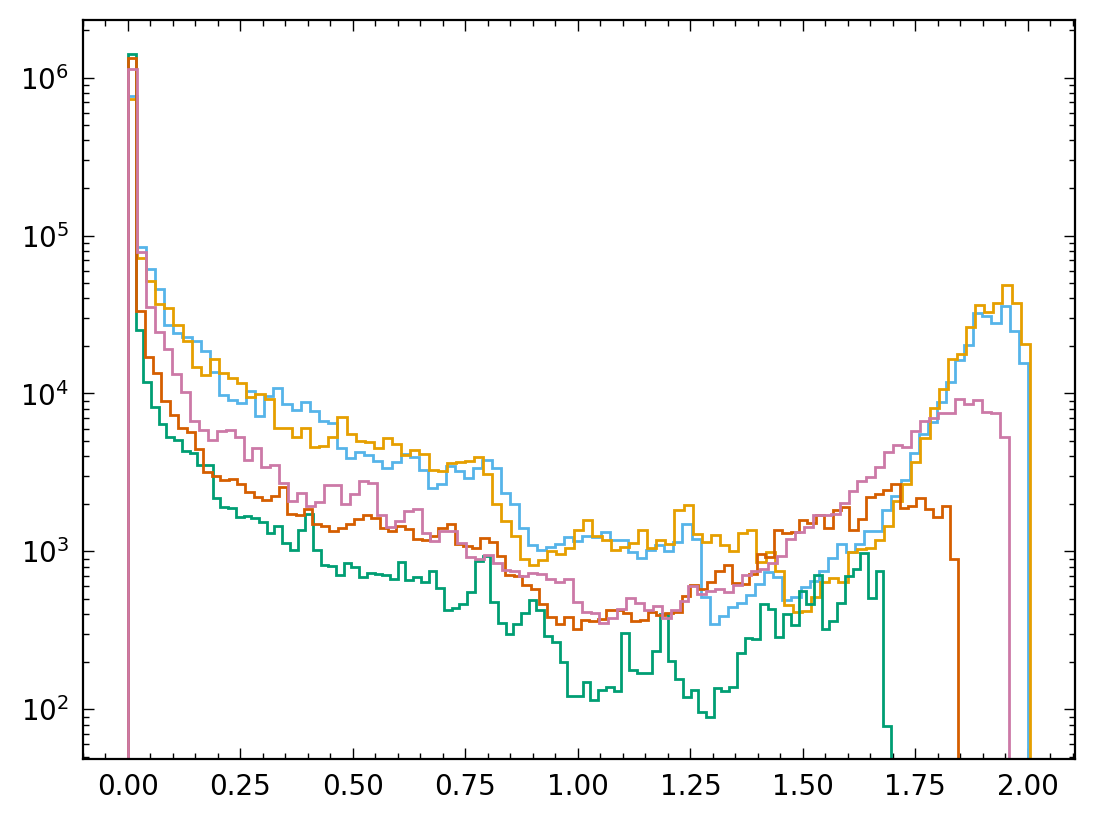

In [4]:
# Inspect distribution of observables
sel = 'peff_clearance'
for a in np.unique(clustered_mean_df.loc[(clustered_mean_df.b_I == b_C)][key_var].values):
    data = clustered_mean_df.loc[clustered_mean_df[key_var] == a]
    plt.hist(data[sel], bins = np.linspace(np.amin(data[sel]), np.amax(data[sel]), 100), histtype = 'step', log = True);

,antigenicity_over_harm,stim_pI,stim_pHI,stim_pHE
0,-26.795884,0.656904,0.409657,0.118486
1,-6.698971,1.251797,0.390651,0.135824
2,0.700124,0.085857,0.481356,0.038727
3,0.717337,0.114835,0.558346,0.050272
4,0.735609,0.142111,0.610145,0.061941
...,...,...,...,...
100,2.677607,1.903008,0.653447,0.115205
101,2.813581,2.039004,0.661223,0.126607
102,3.349485,0.011626,0.482808,0.034804
103,5.359177,0.060155,0.473715,0.045272


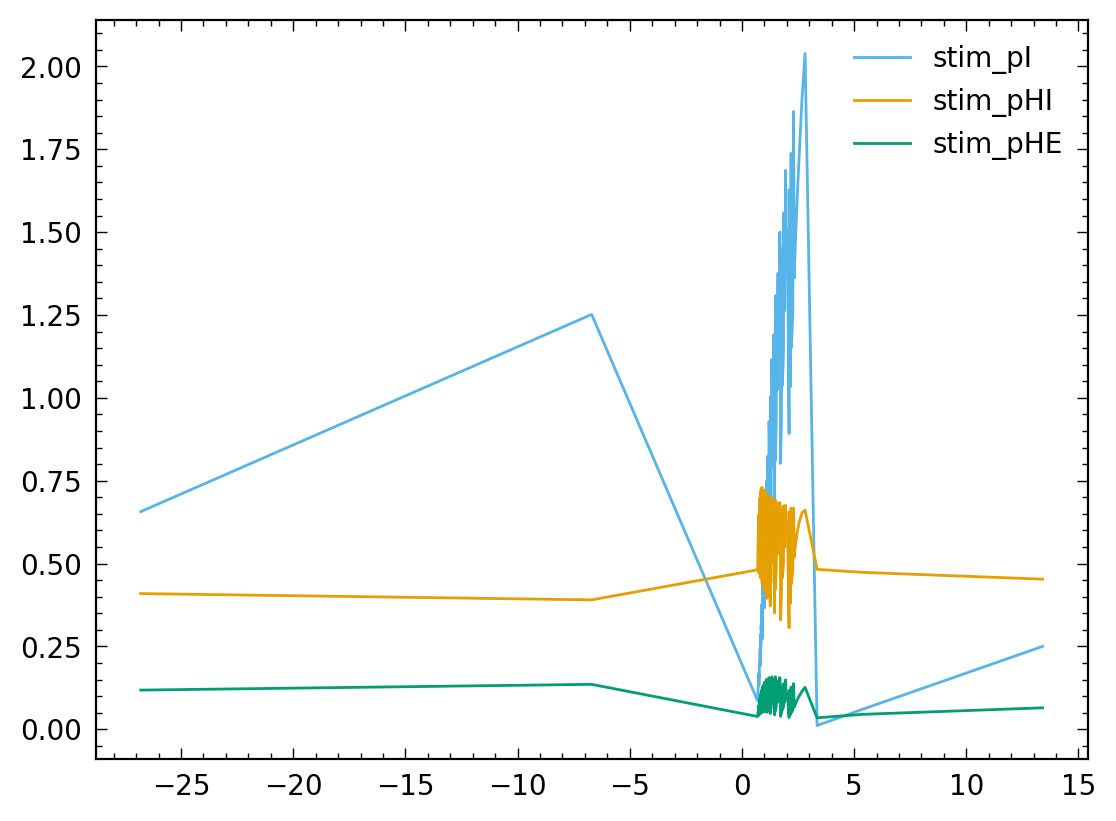

In [5]:
norm_stim = clustered_mean_df.loc[(np.sum(np.abs(clustered_mean_df[reg_stim]), axis = 1) == 0)].groupby(key_var, as_index = False).mean()[[key_var, 'stim_pI', 'stim_pHI', 'stim_pHE']]
with pd.option_context('display.max_columns', None):
    display(norm_stim)
    
plt.plot(norm_stim[key_var], norm_stim[['stim_pI', 'stim_pHI', 'stim_pHE']], label = ['stim_pI', 'stim_pHI', 'stim_pHE'])
plt.legend()

### Fit model to average data
The nonlinear sigmoid model does a good job on the data averaged over infections and marginalized over modules. This is the minimum we require.

fevals: 12
fevals: 11
fevals: 9
fevals: 11


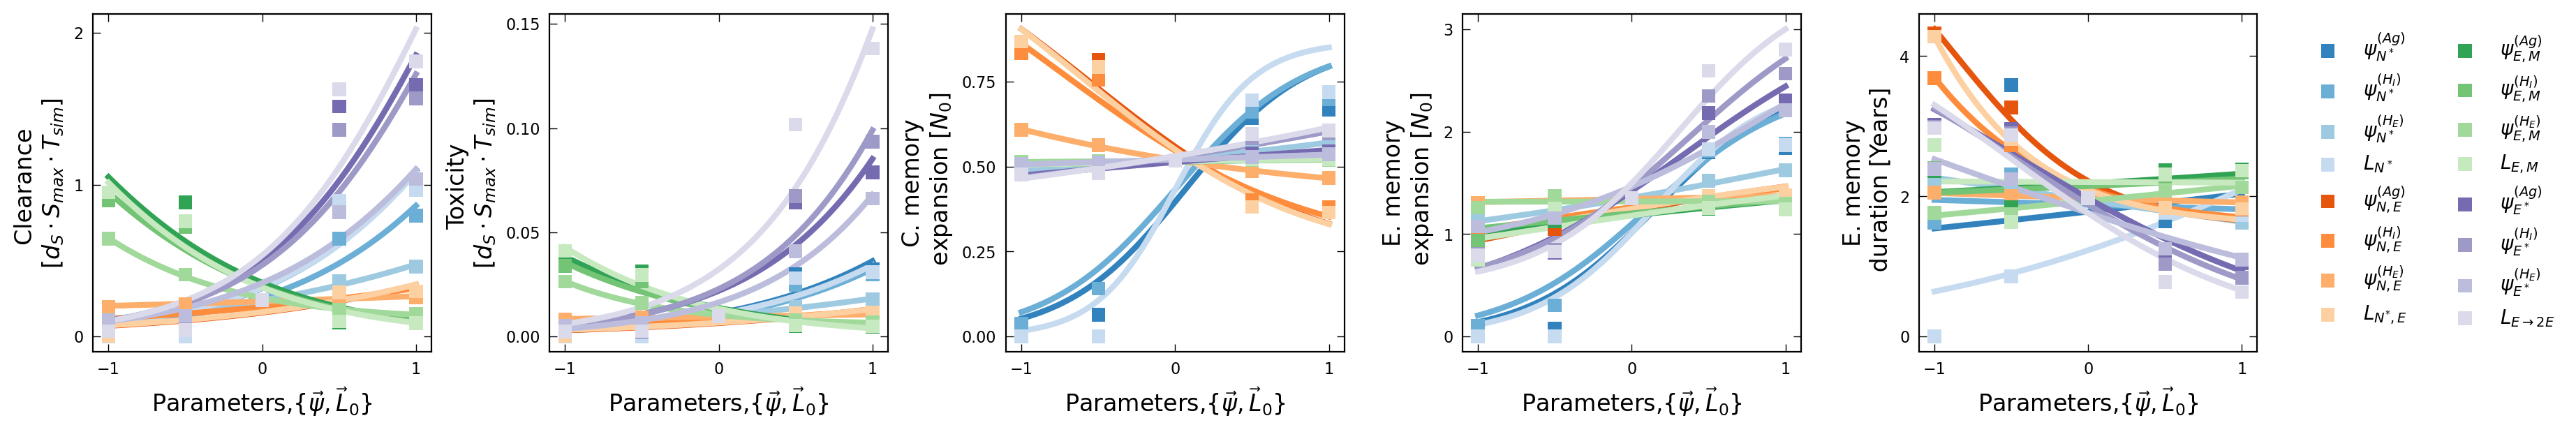

In [6]:
# Fit impact of regulatory parameters on performace: marginalizing over modules

fig, axs = plt.subplots(1, len(perf_vars), 
                              figsize=(len(perf_vars)**2 - len(perf_vars), 4), sharex=True, sharey=False)

for module_index in np.arange(0, len(modules)):
    reg_choice_label = modules[module_index]
    reg_choice = module_reg[reg_choice_label]
    zero_regs = np.concatenate([(module_reg[modules[u]] if u != module_index else []) for u in np.arange(0, len(modules))]).tolist()
    
    x_varname= key_var

    data = clustered_mean_df.loc[(np.sum(np.abs(clustered_mean_df[zero_regs]), axis = 1) == 0.0)]
    
    for i, var in enumerate(perf_vars):
        
        for j, p in enumerate(signal_classes):
            data_mean = data.loc[(np.sum(np.abs(data[reg_choice]), axis = 1) == np.abs(data[reg_choice[j]]))].groupby(reg_choice[j], as_index = False).mean()
            im = axs[i].scatter(data_mean[reg_choice[j]]/np.amax(data_mean[reg_choice[j]]), data_mean[var], 
                              marker = 's', s = 50, color = cmap_colors[module_index*len(reg_choice) + j], 
                                edgecolors = 'None',label = reg_label[module_index*len(reg_choice) + j ])

            y_max = np.max(data[var].values)
            y_min = np.min(data[var].values)
            y_std = np.std(data[var].values)

            #if var != 'T_max_pI':
            popt, pcov, infodict, _, _ = curve_fit(sigmoid_1d, data_mean[reg_choice[j]].values, data_mean[var].values, 
                                   p0 =(y_max - y_min, y_min, 0.0, 0.0),
                                   method = 'trf', 
                                   bounds = ([y_max - y_min, np.minimum(5*y_min, 0), -2*L0_max, -2*L0_max], 
                                             [5*(y_max - y_min) if (y_max - y_min) > 0 else y_std + 0.1, np.maximum(y_min, 0) + y_std + 0.1, 2*L0_max, 2*L0_max]),
                                   maxfev=5000,
                                   full_output = True)

            x = np.linspace(-np.max(data_mean[reg_choice[j]]), np.max(data_mean[reg_choice[j]]), 100)
            axs[i].plot(x/np.amax(x), sigmoid_1d(x, *popt), 
                        linestyle='-',
                        linewidth = 3.0,
                        color = cmap_colors[module_index*len(reg_choice) + j], 
                        zorder = 0)

            if module_index + j == 0: 
                axs[i].minorticks_off()
                axs[i].yaxis.set_tick_params(labelbottom=True)
                axs[i].xaxis.set_tick_params(labelbottom=True)
                axs[i].tick_params(axis='both', which='major', labelsize=8)
                axs[i].set_box_aspect(1)
                axs[i].locator_params(axis='y', nbins=4)
                axs[i].locator_params(axis='x', nbins=4)
                axs[i].set_ylabel(perf_labels[i], fontsize = 12)
                axs[i].set_xlabel(r'Parameters,$\{\vec\psi, \vec L_0 \}$', fontsize = 12)

        if i == 0:
            print("fevals:", infodict['nfev'])

axs[-1].legend(bbox_to_anchor=(1.1, 1), fontsize=10, framealpha=0, ncol = 2)
fig.subplots_adjust(wspace=.35, hspace=.35)
plt.savefig('_figs/'+comment+'-'+'regulation_trends_by_performance'+'.png', dpi=150, bbox_inches="tight")
# del data

fevals: 10
fevals: 9
fevals: 8
fevals: 8


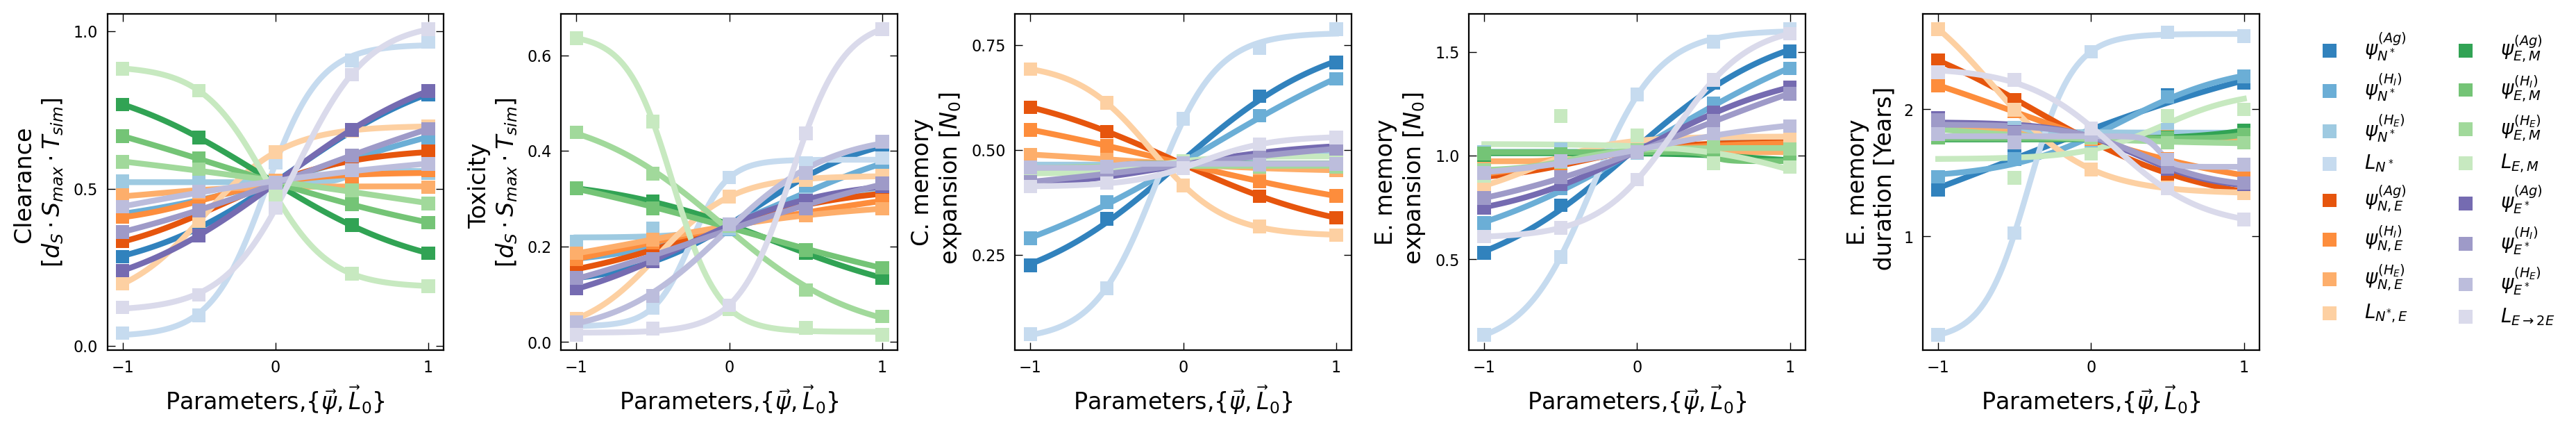

In [7]:
# Fit impact of regulatory parameters on performace: marginalizing over modules
fig, axs = plt.subplots(1, len(perf_vars), 
                              figsize=(len(perf_vars)**2 - len(perf_vars), 4), sharex=True, sharey=False)

for module_index in np.arange(0, len(modules)):
    reg_choice_label = modules[module_index]
    reg_choice = module_reg[reg_choice_label]
    zero_regs = np.concatenate([(module_reg[modules[u]] if u != module_index else []) for u in np.arange(0, len(modules))]).tolist()
    
    x_varname= key_var
    
    for i, var in enumerate(perf_vars):
        
        for j, p in enumerate(signal_classes):
            data_mean = clustered_mean_df.groupby(reg_choice[j], as_index = False).mean()
            im = axs[i].scatter(data_mean[reg_choice[j]]/np.amax(data_mean[reg_choice[j]]), data_mean[var], 
                              marker = 's', s = 50, color = cmap_colors[module_index*len(reg_choice) + j], 
                                edgecolors = 'None',label = reg_label[module_index*len(reg_choice) + j ])

            y_max = np.max(data_mean[var].values)
            y_min = np.min(data_mean[var].values)
            y_std = np.std(data_mean[var].values)

            popt, pcov, infodict, _, _ = curve_fit(sigmoid_1d, data_mean[reg_choice[j]].values, data_mean[var].values, 
                                   p0 =(y_max - y_min, y_min, 0.0, 0.0),
                                   method = 'trf', 
                                   bounds = ([y_max - y_min, np.minimum(5*y_min, 0), -2*L0_max, -2*L0_max], 
                                             [5*(y_max - y_min) if (y_max - y_min) > 0 else y_std + 0.1, np.maximum(y_min, 0) + y_std + 0.1, 2*L0_max, 2*L0_max]),
                                   maxfev=5000,
                                   full_output = True)

            x = np.linspace(-np.max(data_mean[reg_choice[j]]), np.max(data_mean[reg_choice[j]]), 100)
            axs[i].plot(x/np.amax(x), sigmoid_1d(x, *popt), 
                        linestyle='-',
                        linewidth = 3.0,
                        color = cmap_colors[module_index*len(reg_choice) + j], 
                        zorder = 0)

            if module_index + j == 0: 
                axs[i].minorticks_off()
                axs[i].yaxis.set_tick_params(labelbottom=True)
                axs[i].xaxis.set_tick_params(labelbottom=True)
                axs[i].tick_params(axis='both', which='major', labelsize=8)
                axs[i].set_box_aspect(1)
                axs[i].locator_params(axis='y', nbins=4)
                axs[i].locator_params(axis='x', nbins=4)
                axs[i].set_ylabel(perf_labels[i], fontsize = 12)
                axs[i].set_xlabel(r'Parameters,$\{\vec\psi, \vec L_0 \}$', fontsize = 12)

        if i == 0:
            print("fevals:", infodict['nfev'])

axs[-1].legend(bbox_to_anchor=(1.1, 1), fontsize=10, framealpha=0, ncol = 2)
fig.subplots_adjust(wspace=.35, hspace=.35)
plt.savefig('_figs/'+comment+'-'+'mean_regulation_trends_by_performance'+'.png', dpi=150, bbox_inches="tight")

In [8]:
# # Fit impact of regulatory parameters on performace: marginalizing over modules
# for module_index in np.arange(0, len(modules)):
#     reg_choice_label = modules[module_index]
#     reg_choice = module_reg[reg_choice_label]
    
#     x_varname= key_var
#     fig_c, axs = plt.subplots(num_categories, len(reg_choice), 
#                               figsize=(len(reg_choice)*len(reg_choice), np.maximum(3.5, len(reg_choice))*num_categories), sharex='col', sharey='row')

#     data = clustered_mean_df.loc[(clustered_mean_df.K_EH == K_EH)].groupby(reg_choice, as_index = False).mean()
    
#     for i, var in enumerate(perf_vars):
        
#         for j, p in enumerate(signal_classes):
#             data_mean = data.groupby(reg_choice[j], as_index = False).mean()
#             im = axs[i, j].scatter(data_mean[reg_choice[j]], data_mean[var], 
#                               marker = 'o', s = 20, edgecolors = 'None')

#             y_max = np.max(data[var].values)
#             y_min = np.min(data[var].values)
#             y_std = np.std(data[var].values)

#             #if var != 'T_max_pI':
#             popt, pcov, infodict, _, _ = curve_fit(sigmoid_1d, data_mean[reg_choice[j]].values, data_mean[var].values, 
#                                    p0 =(y_max - y_min, y_min, 0.0, 0.0),
#                                    method = 'trf', 
#                                    bounds = ([y_max - y_min, np.minimum(5*y_min, 0), -2*psi_max, -2*psi_max], 
#                                              [5*(y_max - y_min) if (y_max - y_min) > 0 else y_std + 0.1, np.maximum(y_min, 0) + y_std + 0.1, 2*psi_max, 2*psi_max]),
#                                    maxfev=5000,
#                                    full_output = True)
  
#             sigma_w = np.sqrt(np.diag(pcov))[-1]

#             x = np.linspace(-np.max(data_mean[reg_choice[j]]), np.max(data_mean[reg_choice[j]]), 100)
#             axs[i, j].plot(x, sigmoid_1d(x, *popt), 'k--')

#             axs[i, j].set_title('fit: $y_{range} =$ %5.3f, $y_{min} =$ %5.3f, \n $b=$ %5.3f, $w=$ %5.3f, $\sigma(w) =$ %5.3f' % tuple(popt.tolist() + [sigma_w]), fontsize = 9.0)
                
#             axs[i, j].minorticks_off()
#             axs[i, j].yaxis.set_tick_params(labelbottom=True)
#             axs[i, j].xaxis.set_tick_params(labelbottom=True)
#             axs[i, j].tick_params(axis='both', which='major', labelsize=8)
#             axs[i, j].set_box_aspect(1)
#             axs[i, j].set_ylabel(perf_labels[i], fontsize = 10)
#             axs[i, j].set_xlabel(reg_label[module_index*len(reg_choice) + j ], fontsize = 10)

#         if i == 0:
#             print("fevals:", infodict['nfev'])
    
#     fig_c.subplots_adjust(wspace=.75, hspace=0.5)
#     plt.savefig('_figs/'+comment+'-'+reg_choice_label+'-mean_regulation_trends_by_performance'+'.png', dpi=150, bbox_inches="tight")
#     del data

In [9]:
del clustered_mean_df

### Fit model to individual infection scenarios and with all regulatory modules as variables

In [26]:
# Regress Performance measures on regulation parameters
num_cpu = 134
variables = reg

def model(input, fit = "non-linear"):

    out = []
    infection = input[vir_vars].values[0]
    runtimes = str(np.round(infection, 3))+': '
    
    for i, perf in enumerate(perf_vars):
        # run regression
        start = time.time() # timestamp start
        
        if fit == "linear":
            input.loc[:,'dep_var'] = np.log(1 + input[perf].values) if 'Memory' in perf_labels[perf_vars.index(perf)] or 'magnitude' in perf_labels[perf_vars.index(perf)] else input[perf].values
            lr = smf.ols('dep_var ~ ' + ' + '.join(variables), data=input).fit()
    
            # save values
            out.append( (lr.params.values[0: 1 + len(variables)]).tolist() + np.sqrt(np.diag(lr.cov_params())).tolist() + infection.tolist() + [np.mean(input[perf].values), i] )
        else:
            y_max = np.max(input[perf].values)
            y_min = np.min(input[perf].values)
            y_std = np.std(input[perf].values)
            popt, pcov = curve_fit(sigmoid, input[variables].values, input[perf].values, 
                           p0 =[y_max - y_min, y_min] + len(variables)*[0.0] + num_modules*[0.0],
                           method = 'trf', 
                           bounds = ([(y_max - y_min)/2, 0.0 if y_min >= 0.0 else 2*y_min] + len(variables)*[-3.0*L0_max] + num_modules*[-3.0*L0_max], 
                                     [(2.5 if perf != "T_eM_min" else 1.0)*(y_max - y_min) if (y_max - y_min) > 0 else y_std + 0.01, y_min if y_min > 0 else + y_std + 0.01] + len(variables)*[3.0*L0_max] + num_modules*[3.0*L0_max]), 
                                   maxfev=100000,
                                   full_output = False)
            
            residuals = input[perf].values - sigmoid(input[variables].values, *popt)
            rmse = np.sqrt(np.mean(residuals**2))
            out.append(popt.tolist() + np.sqrt(np.diag(pcov)).tolist() + infection.tolist() + [np.mean(input[perf].values), 
                                                                                               np.max(input[perf].values), 
                                                                                               np.min(input[perf].values), 
                                                                                               np.median(input[perf].values), 
                                                                                               i, rmse, y_std, input['harm_pI_noprotection'].values[0],
                                                                                               np.mean(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pI'].values), 
                                                                                               np.mean(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pHI'].values),
                                                                                               np.mean(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pHE'].values)])

            # if i == 0:
            #     print("fevals:", infodict['nfev'])
        end = time.time() # timestamp start
        runtimes += (perf+ ' = ' + str((end - start)/3600)+' hrs, ')
        
    #print(runtimes)
    out_data = pd.DataFrame(np.vstack(out), 
                            columns = ['y_range', 'y_min'] \
                            + variables + [('intercept_' + j) for j in modules] \
                            + ['sigma_y_max', 'sigma_y_min'] + ['sigma_'+r  for r in variables] \
                            + [('sigma_intercept_' + j) for j in modules] \
                            + vir_vars \
                            + ['mean_perf', 'max_perf', 'min_perf', 'median_perf', 'perf_index', 'rmse', 'y_std', 'harm_pI_noprotection', 'stim_pI', 'stim_pHI', 'stim_pHE'])
    out_data['antigenicity_over_harm'] = antigenicity_over_harm(out_data)
    out_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/fits/'+comment+runs+'fit_'+str(np.round(infection, 3))+'.pkl')
    
    return np.vstack(out)

# Compile datasets
impact_data = pd.DataFrame(np.vstack(Parallel(n_jobs = num_cpu, batch_size = max(int(n_virs/num_cpu),1))(delayed(model)(input = data.groupby(vir_vars + variables, as_index=False).mean(), fit = "nonlinear") 
                                                                                                            for data in infection_scenarios)), 
                            columns = ['y_range', 'y_min'] \
                            + variables + [('intercept_' + j) for j in modules] \
                            + ['sigma_y_max', 'sigma_y_min'] + ['sigma_'+r  for r in variables] \
                            + [('sigma_intercept_' + j) for j in modules] \
                            + vir_vars \
                            + ['mean_perf', 'max_perf', 'min_perf', 'median_perf', 'perf_index', 'rmse', 'y_std', 'harm_pI_noprotection', 'stim_pI', 'stim_pHI', 'stim_pHE'])
impact_data['antigenicity_over_harm'] = antigenicity_over_harm(impact_data)

impact_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')

In [27]:
# # IF the above fails: Compile datasets
# num_cpu = 150
# file_list = [f for f in os.listdir(d) if comment in f]
# num_files = len(file_list)

# def import_fits(f,d):
    
#     file_path = os.path.join(d, f)
#     with open(file_path, 'rb') as filename:  
#         out = pickle.load(filename)

#     return out

# impact_data = pd.concat(Parallel(n_jobs = num_cpu, batch_size = max(int(n_virs/num_cpu),1))(delayed(import_fits)(f = file_name, d = d) 
#                                                                                                             for file_name in file_list))
# impact_data['antigenicity_over_harm'] = antigenicity_over_harm(impact_data)

# impact_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')

In [44]:
# View result
perf_choice = 4 # chose observable
impact_data = pd.read_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf_choice)])

,y_range,y_min,psi_Na_I,psi_Na_HI,psi_Na_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_EE_I,psi_EE_HI,psi_EE_HE,L0_EE,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_Na_I,sigma_psi_Na_HI,sigma_psi_Na_HE,sigma_L0_Na,sigma_psi_NE_I,sigma_psi_NE_HI,sigma_psi_NE_HE,sigma_L0_NE,sigma_psi_EM_I,sigma_psi_EM_HI,sigma_psi_EM_HE,sigma_L0_EM,sigma_psi_EE_I,sigma_psi_EE_HI,sigma_psi_EE_HE,sigma_L0_EE,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_IE,b_I,K_EH,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,harm_pI_noprotection,stim_pI,stim_pHI,stim_pHE,antigenicity_over_harm
4,5.0,0.262239,0.492997,2.247953,-0.001331,7.610505,-0.010256,-0.022107,-0.000552,-0.234046,-0.126627,0.016399,-0.102359,0.128313,-0.060599,-0.023559,-0.012396,-0.726343,-2.560749,2.860536,9.913864,1.827603,0.034447,0.002356,0.010958,0.021040,0.009406,13.332722,0.008229,0.008249,0.008170,0.010499,14.099260,9.882416,12.684013,14.426815,0.003749,0.003741,0.003740,0.003285,0.018093,0.067540,133.704487,0.010622,0.01,100000000.0,0.0,50000.0,100.000000,10000000.0,0.0,1.644766,5.0,0.0,0.264489,4.0,0.886505,2.076034,0.000000,0.040967,0.026400,0.007788,NaN
9,5.0,0.267955,0.611029,2.808493,0.000507,8.211859,-0.010183,-0.021395,-0.000396,-0.224259,-0.115866,0.003682,-0.194567,0.128037,-0.060919,-0.019890,-0.024100,-0.767133,-2.416353,2.841925,10.192267,1.847506,0.029397,0.002322,0.012284,0.028751,0.010178,9.340602,0.008237,0.008259,0.008177,0.010636,14.373323,11.610503,19.016820,14.694615,0.003793,0.003785,0.003785,0.003480,0.016159,0.069899,138.896491,0.010696,0.01,100000000.0,0.0,50000.0,234.034732,10000000.0,0.0,1.647591,5.0,0.0,0.298087,4.0,0.876440,2.071260,0.000000,0.040966,0.026400,0.015175,NaN
14,5.0,0.266074,0.553655,3.161188,-0.012875,8.457827,-0.009443,-0.021616,-0.000945,-0.219498,-0.511326,-0.175028,-0.797317,0.200414,-0.058638,-0.015360,-0.044976,-0.777812,-2.002686,2.818920,10.184081,1.870637,0.017982,0.002362,0.012711,0.037460,0.011787,10.722399,0.008282,0.008307,0.008222,0.010749,2.085866,1.000251,3.514422,0.841659,0.003866,0.003858,0.003862,0.003590,0.011914,0.071450,12.796821,0.010945,0.01,100000000.0,0.0,50000.0,547.722558,10000000.0,0.0,1.666930,5.0,0.0,0.320441,4.0,0.888849,2.069859,0.000000,0.040963,0.026400,0.026614,NaN
19,5.0,0.255806,0.408984,3.671128,-0.014150,8.606623,-0.011605,-0.022445,-0.001777,-0.214747,-0.097033,-0.050442,-1.243466,0.225246,-0.053968,-0.011467,-0.074813,-0.776628,-1.506946,2.776605,9.704752,1.922458,0.019197,0.002462,0.012648,0.105059,0.012896,8.257894,0.008332,0.008359,0.008269,0.010865,0.358611,0.344736,2.714493,0.374166,0.003995,0.003988,0.004002,0.003702,0.008639,0.073122,8.576331,0.011456,0.01,100000000.0,0.0,50000.0,1281.861019,10000000.0,0.0,1.697984,5.0,0.0,0.333922,4.0,0.921076,2.073801,0.000000,0.040957,0.026400,0.043013,NaN
24,5.0,0.241597,0.346152,6.445083,-0.014992,14.375303,-0.009837,-0.022078,-0.003740,-0.207847,-0.033571,-0.017896,-1.211636,0.241740,-0.053560,-0.009032,-0.122778,-0.783429,-1.022632,2.691685,9.268295,2.040213,0.021267,0.002633,0.012111,11.767324,0.011881,7253.815917,0.008283,0.008315,0.008224,0.010902,0.251298,0.250113,1.803857,0.293300,0.004253,0.004245,0.004288,0.003951,0.006900,0.074818,5.781292,0.012521,0.01,100000000.0,0.0,50000.0,3000.000000,10000000.0,0.0,1.740356,5.0,0.0,0.341479,4.0,0.978270,2.089887,0.000000,0.040944,0.026400,0.064762,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629,5.0,0.328291,0.370500,5.315272,-0.002236,4.436288,-0.011453,-0.116764,-0.000029,-0.200292,-0.020158,-2.066463,-0.006362,0.887379,-0.088937,-0.806179,-0.010569,-0.772714,-2.642304,2.644504,13.743063,1.811418,0.022160,0.002574,0.010441,0.048004,0.009043,0.038776,0.0082

#### Check the model goodness of the fit
The model does a pretty good job as the $R^2$ values for clearance, toxicity and memory are above 0.80.

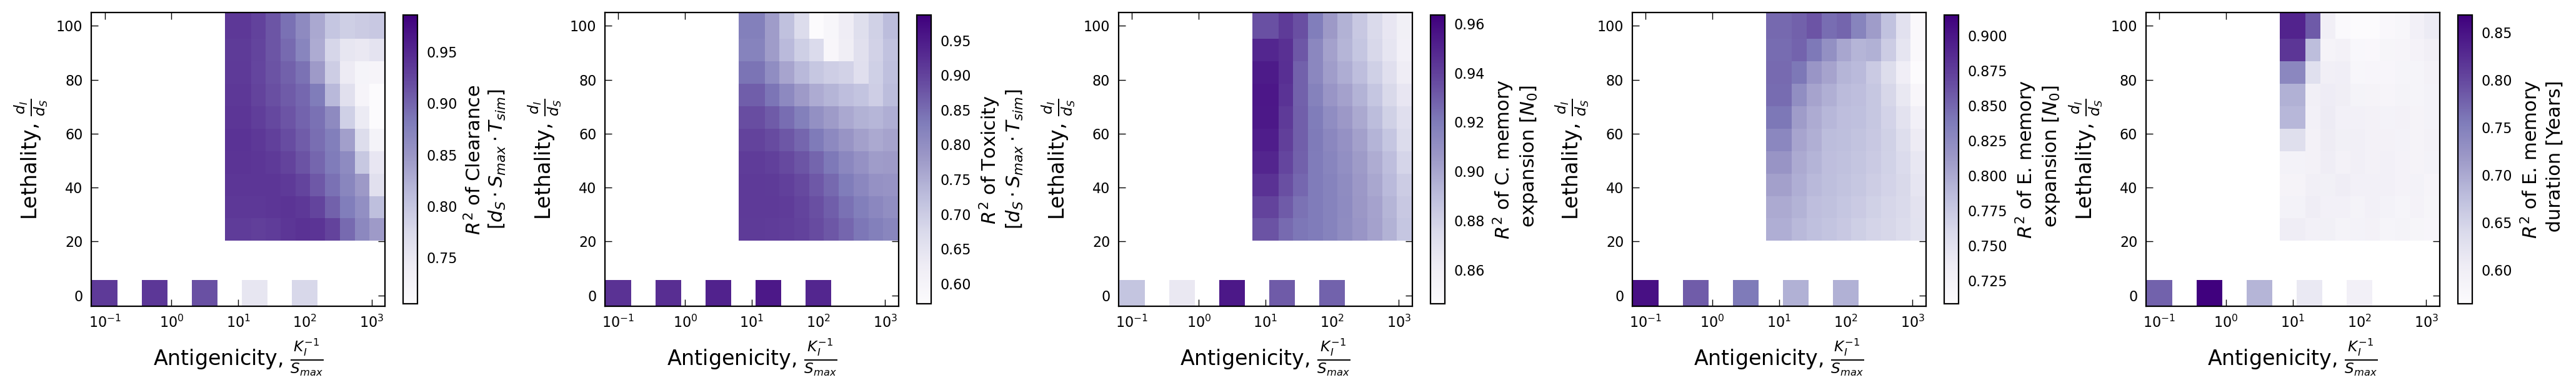

In [29]:
# Examine goodness of fit through R-squared
plots = [vir_vars[1], vir_vars[0]]
plot_labels = ["Antigenicity, "+r"$\frac{K_{I}^{-1}}{S_{max}}$", "Lethality, "+r"$\frac{d_{I}}{d_{S}}$"]
size = 2500/np.sqrt(len(infection_scenarios))

fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)]
    model_r_sq = 1 - data.rmse**2/data.y_std**2
    z_label = r"$R^2$ of "+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname] if x_varname == 'K_IE' else data[x_varname]/d_S,
                                 data['S_0']/data[y_varname] if y_varname == 'K_IE' else data[y_varname]/d_S,
                      marker ='s', s = size, c = model_r_sq, cmap='Purples', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_IE':
        axs[i].semilogx()
    if y_varname == 'K_IE':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.40, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-r-squared'+'.png', dpi=150, bbox_inches="tight")

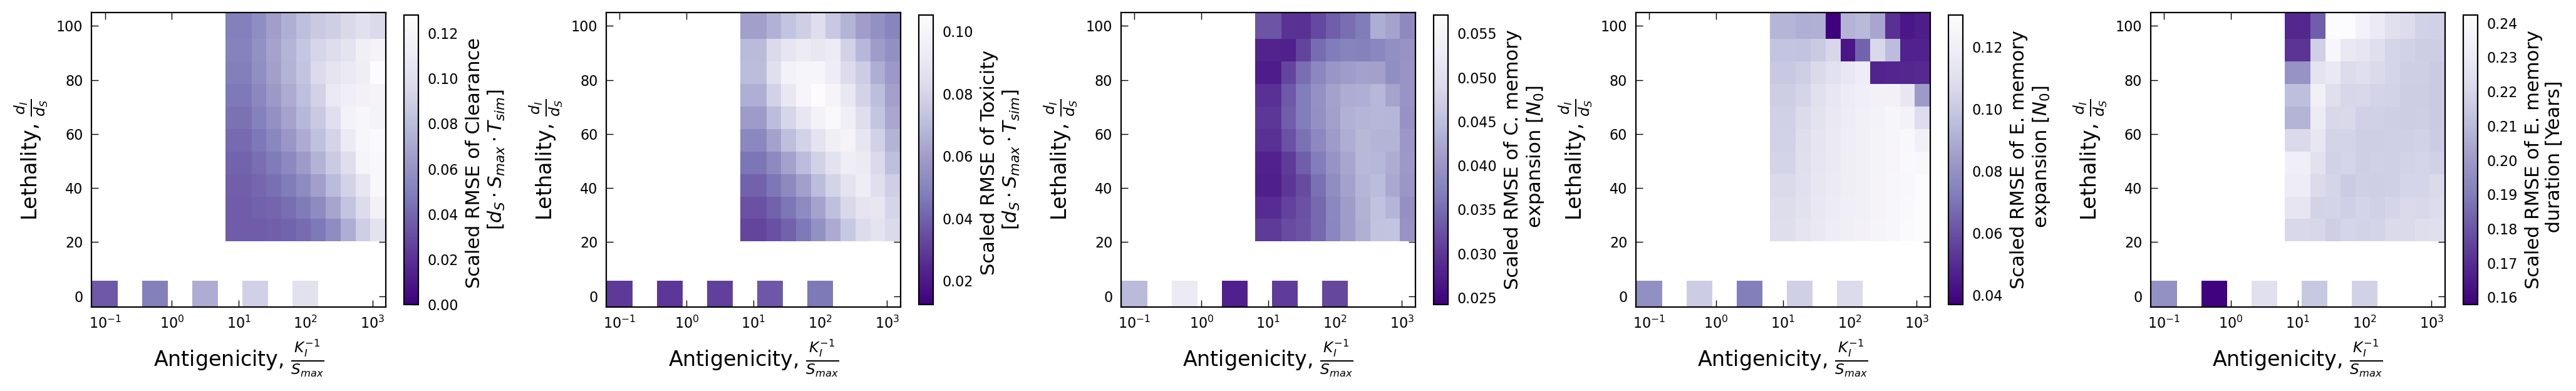

In [30]:
# Examine goodness of fit through scaled-RMSE
fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)]
    model_rmse_over_max = data.rmse/data.y_range
    z_label = "Scaled RMSE of "+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname] if x_varname == 'K_IE' else data[x_varname]/d_S,
                                 data['S_0']/data[y_varname] if y_varname == 'K_IE' else data[y_varname]/d_S,
                      marker ='s', s = size, 
                        c = model_rmse_over_max, cmap='Purples_r', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_IE':
        axs[i].semilogx()
    if y_varname == 'K_IE':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.40, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-scaled-rmse'+'.png', dpi=150, bbox_inches="tight")

Effector memory expansion appears challenging to fit based on the $R^2$ values. Looks much better when we look at scaled RMSE. Rationalize by observing tha effector memory expansion has non-monotonic dependence on some variables which can lead to a low variance estimate, and make the $R^2$ values look bad.

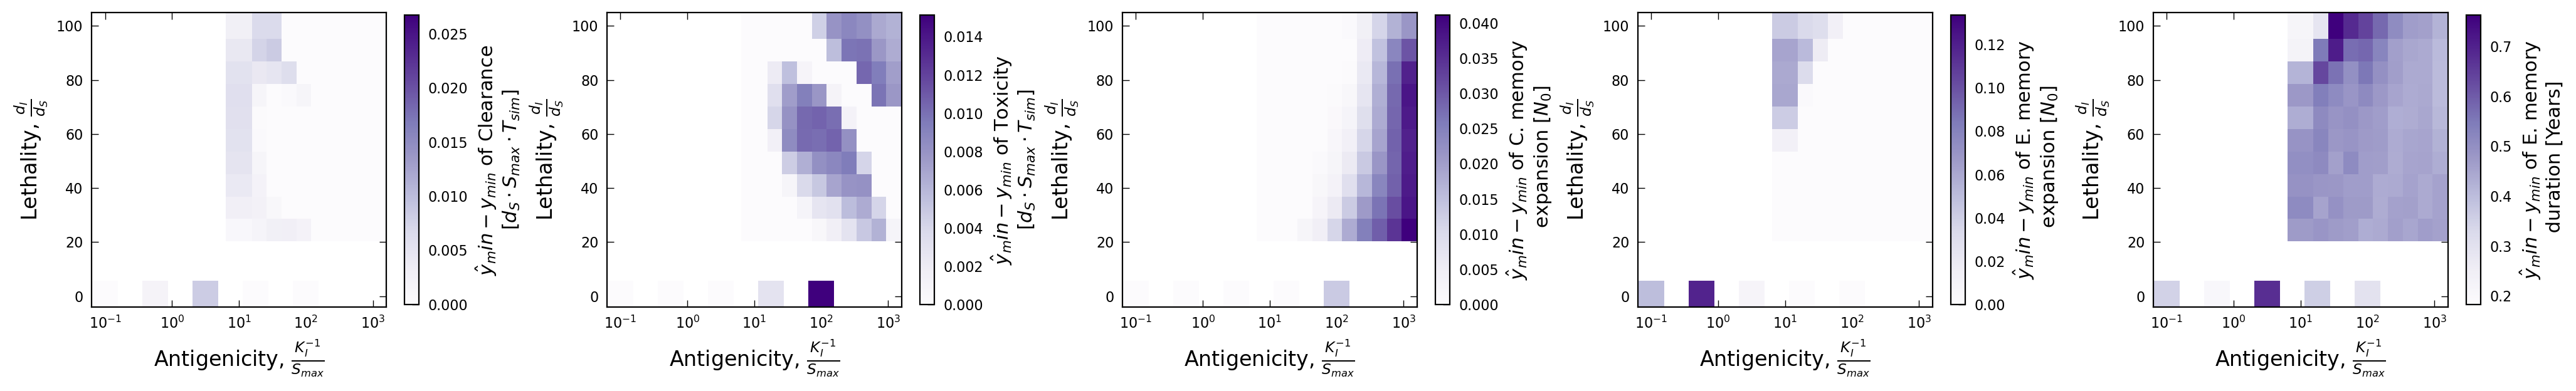

In [31]:
# Examine difference between observed and predicted minima
fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)]
    z_label = r"$\hat{y}_min - y_{min}$ of "+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname] if x_varname == 'K_IE' else data[x_varname]/d_S,
                                 data['S_0']/data[y_varname] if y_varname == 'K_IE' else data[y_varname]/d_S,
                      marker ='s', s = size, c = data.y_min - data.min_perf, cmap='Purples', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_IE':
        axs[i].semilogx()
    if y_varname == 'K_IE':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.40, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-y_min'+'.png', dpi=150, bbox_inches="tight")

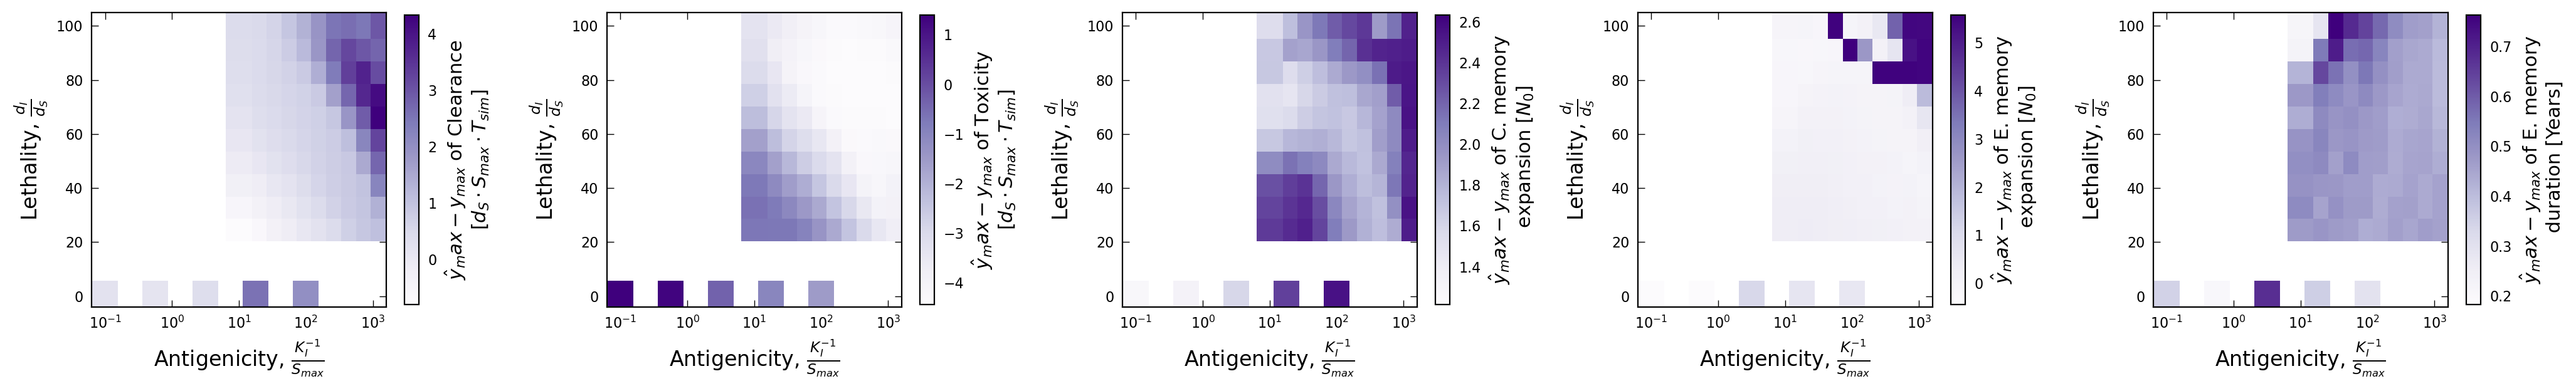

In [32]:
# Examine difference between observed and predicted maxima
plots = [vir_vars[1], vir_vars[0]]

fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)]
    z_label = r"$\hat{y}_max - y_{max}$ of "+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname] if x_varname == 'K_IE' else data[x_varname]/d_S,
                                 data['S_0']/data[y_varname] if y_varname == 'K_IE' else data[y_varname]/d_S,
                      marker ='s', s = size, c = data.y_range + data.y_min - data.max_perf, cmap='Purples', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_IE':
        axs[i].semilogx()
    if y_varname == 'K_IE':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.40, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-y_max'+'.png', dpi=150, bbox_inches="tight")

The distribution of the values of the bias parameters gives us a sense of how well our simulations can explain variation due to that module. In this case the Naive to Memory module has a computed bias for clearance/toxicity that is at the maximum allowable. However the value is less extreme for memory formation. This suggests a strong bias towards high clearance/toxicity in this module.

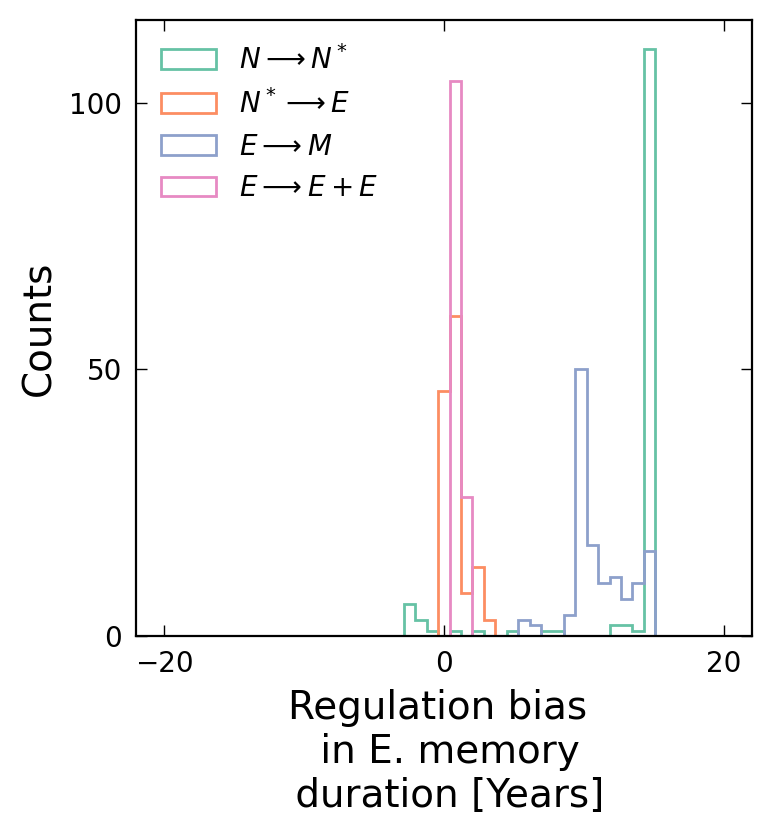

In [43]:
fig, axs = plt.subplots(figsize=(4,4), sharex=False, sharey=False)

cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
for i, r in enumerate(modules):
    data = impact_data[(impact_data.perf_index == perf_choice)*(impact_data['K_EH'] == K_EH)]['intercept_'+r].values
    axs.hist(data, bins = np.linspace(-4*L0_max, 4*L0_max, 50), histtype = 'step', label = module_labels[i], color = cmap_colors[i], stacked = True);

axs.legend(fontsize = 10, ncol = 1)

axs.set_xlabel("Regulation bias \n in "+perf_labels[perf_choice], fontsize = 14)
axs.set_ylabel("Counts", fontsize = 14)
axs.set_box_aspect(1)
axs.minorticks_off()
axs.locator_params(axis='y', nbins=4)
axs.locator_params(axis='x', nbins=4)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

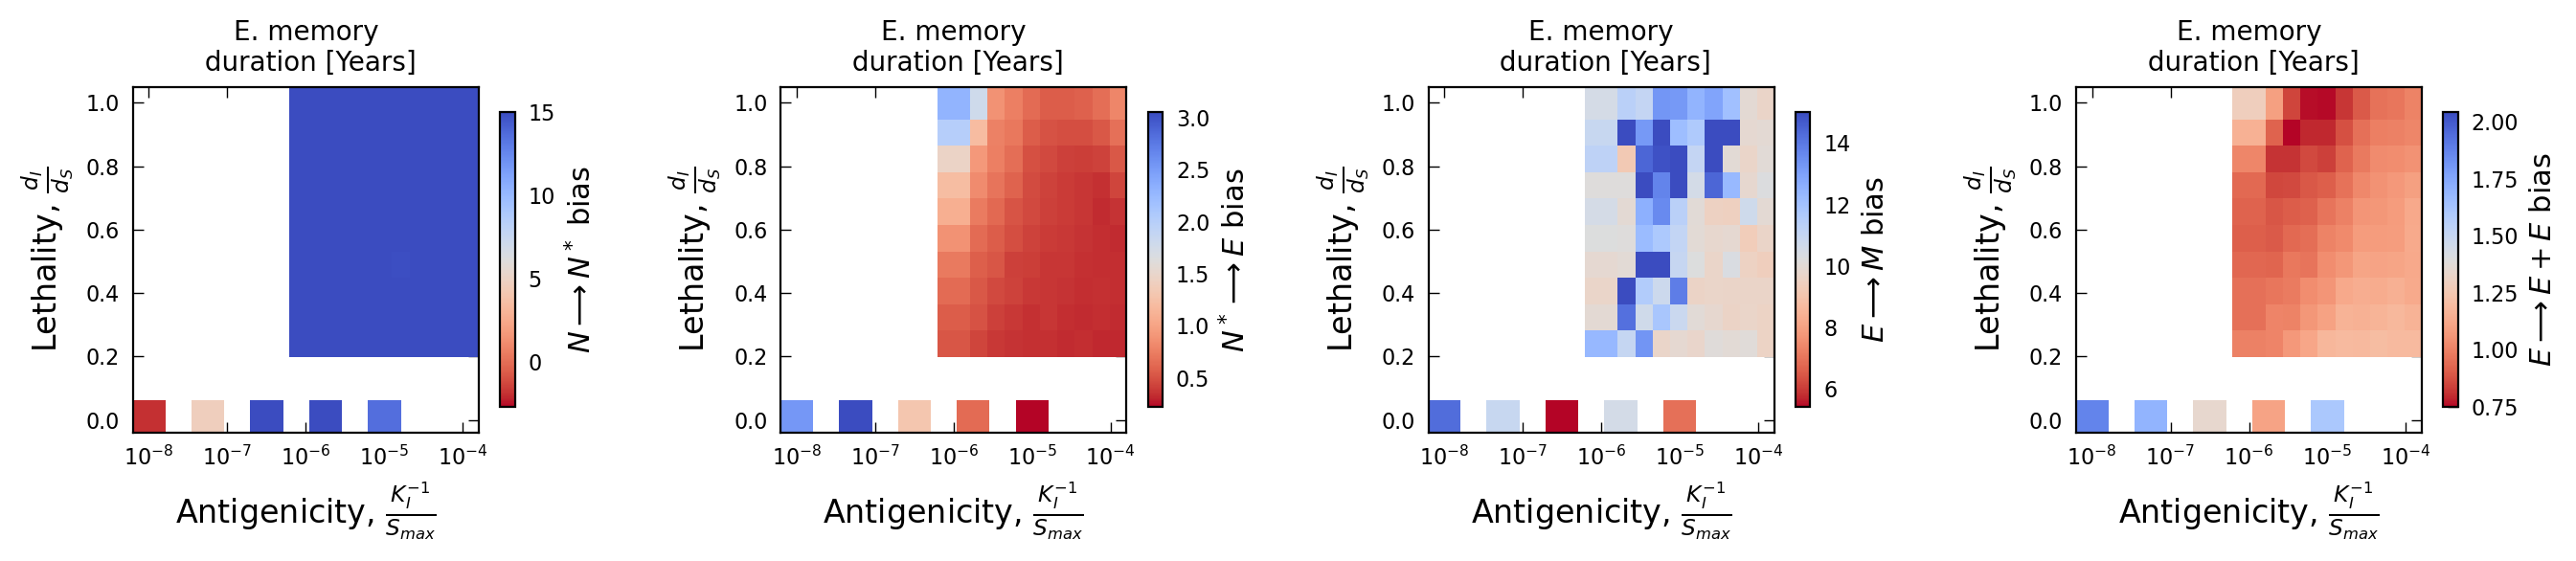

In [40]:
# Visualize optimal regulation
plots = [vir_vars[1], vir_vars[0]]
size = 1750/np.sqrt(len(infection_scenarios))

data = impact_data[(impact_data.perf_index == perf_choice)*(impact_data['K_EH'] == K_EH)]

fig_c, axs = plt.subplots(1, len(modules), 
                          figsize=(len(modules)**2, 2*len(modules)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, r in enumerate(modules):
    z_varname = 'intercept_'+r
    z_label = module_labels[i]+" bias"
    
    im = axs[i].scatter(1/data[x_varname] if x_varname == 'K_IE' else data[x_varname],
                                 1/data[y_varname] if y_varname == 'K_IE' else data[y_varname],
                      marker ='s', s = size, c = data[z_varname], cmap='coolwarm_r', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_IE':
        axs[i].semilogx()
    if y_varname == 'K_IE':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)
    axs[i].set_title(perf_labels[perf_choice], fontsize = 10.0)

    cb = fig_c.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.25, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig_c.subplots_adjust(wspace=.5, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

# plt.savefig('_figs/'+comment+'-optimal-reg-average_prot_tox_hmap'+'.png', dpi=150, bbox_inches="tight")

These intercept values are important because they tell you what the value of the observable would be if we ran our processes, without regulation, at half their maximal characteristic rates. A positive value means that the half-max rate leads to above-median performance/cost. It would be useful to convert these to rates.

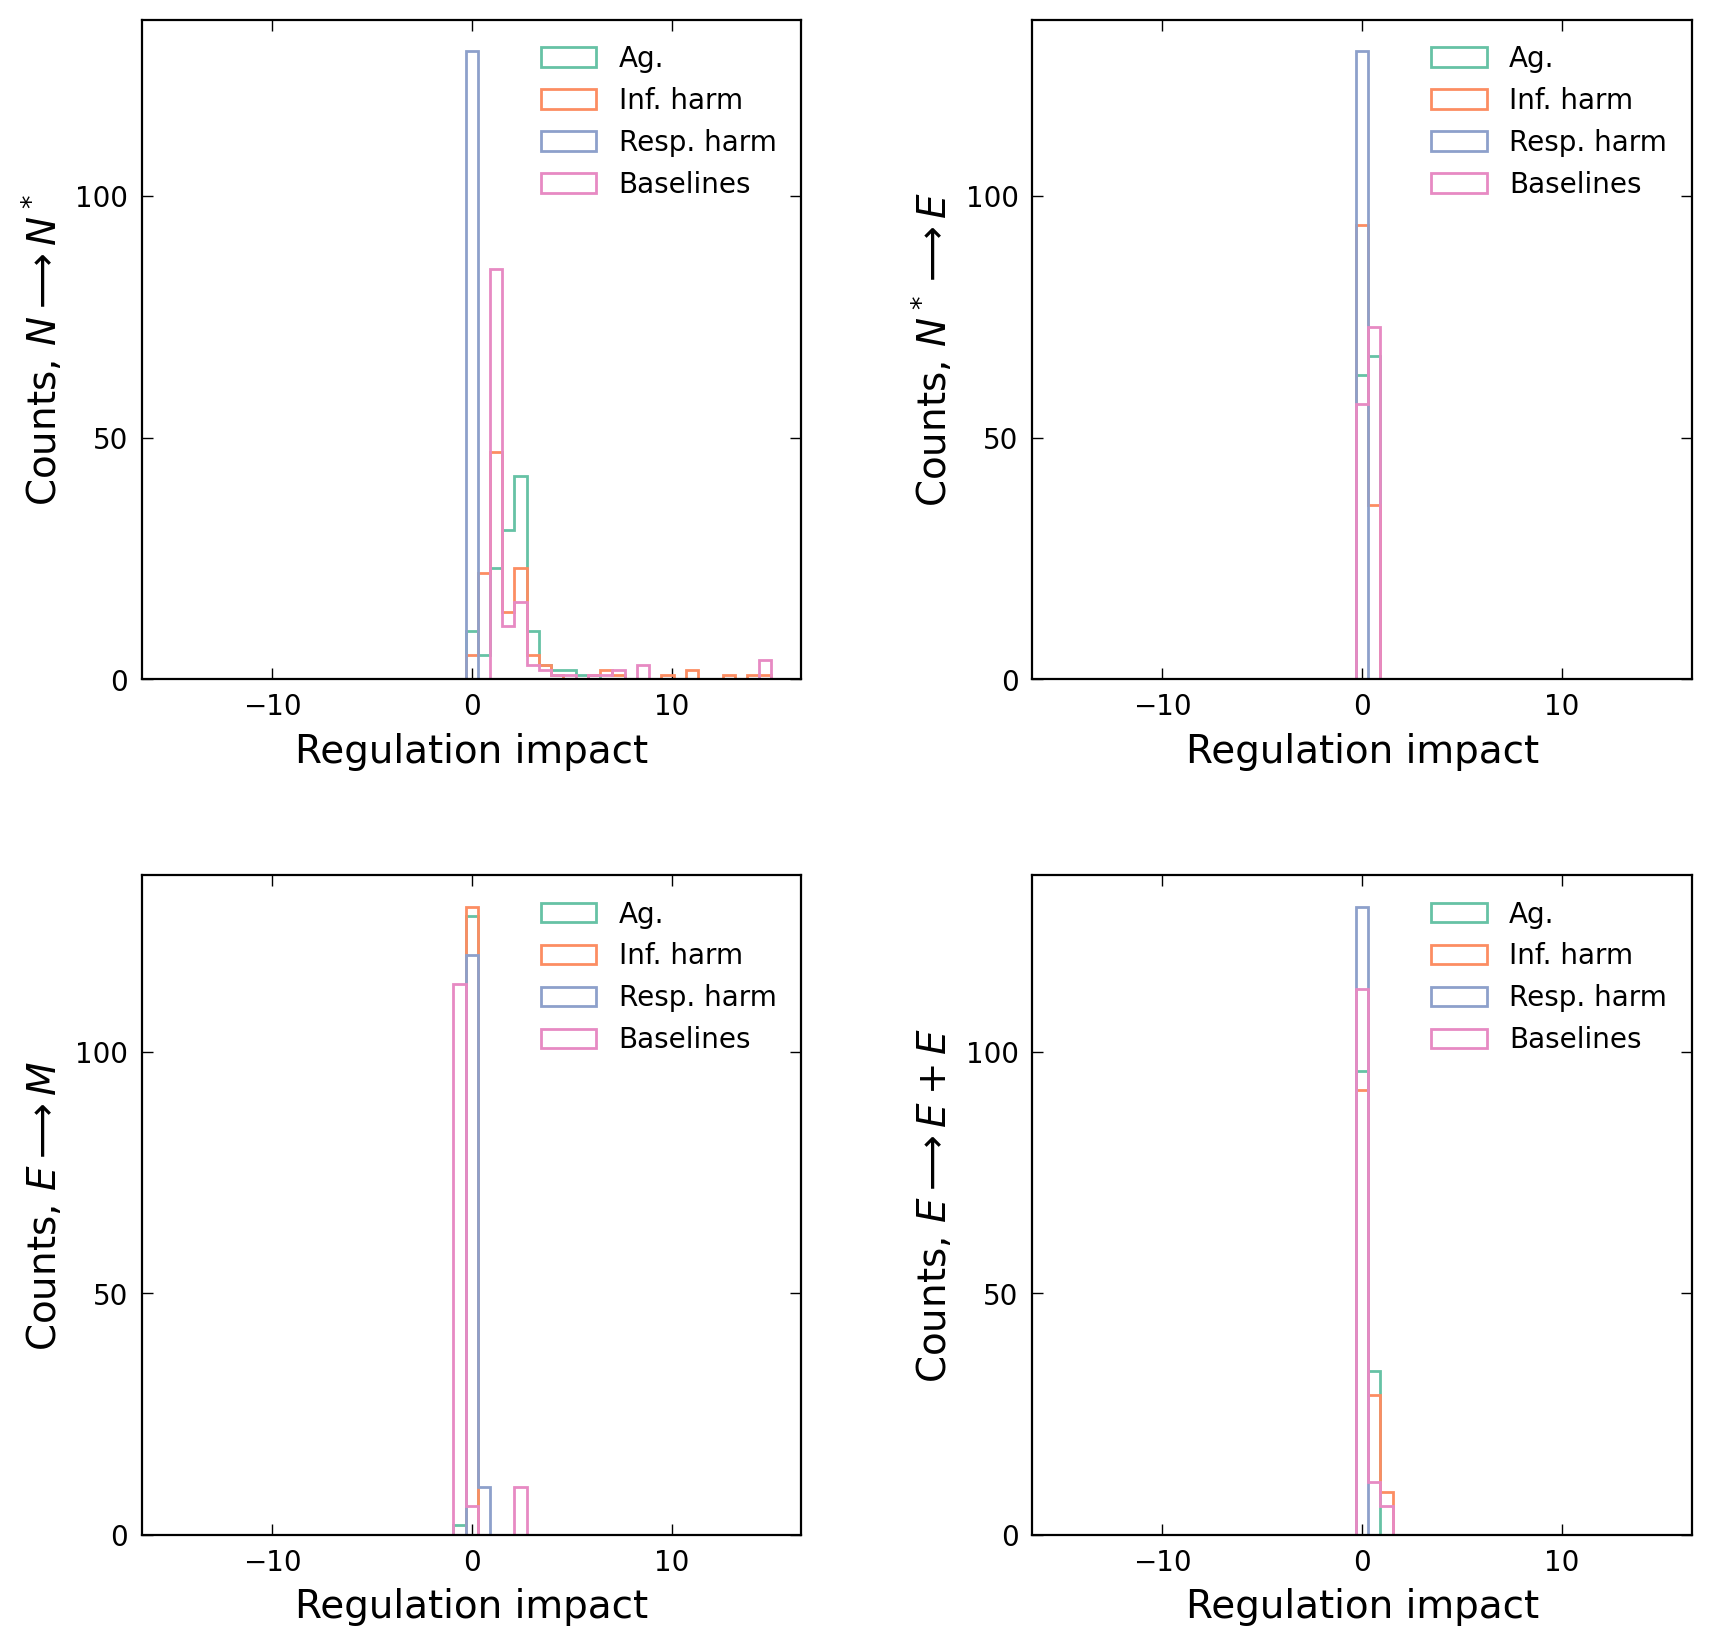

In [35]:
fig, axs = plt.subplots(2,2, figsize=(10,10), sharex=False, sharey=False)

for i, r in enumerate(reg):
    data = impact_data[(impact_data.perf_index == perf_choice)*(impact_data['K_EH'] == K_EH)][r].values
    module = i // num_modules
    cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
    
    x, y = module // 2, module % 2
    axs[x,y].hist(data, bins = np.linspace(-3.0*L0_max, 3.0*L0_max, 50), histtype = 'step', label = signal_classes[i % num_modules], color = cmap_colors[i % num_modules], stacked = True);

    if (i % num_modules) == num_modules -1:
        axs[x,y].legend(fontsize = 10, ncol = 1)
    
        axs[x,y].set_xlabel("Regulation impact", fontsize = 14)
        axs[x,y].set_ylabel("Counts, "+module_labels[i // num_modules], fontsize = 14)
        axs[x,y].set_box_aspect(1)
        axs[x,y].minorticks_off()
        axs[x,y].locator_params(axis='y', nbins=4)
        axs[x,y].locator_params(axis='x', nbins=4)

fig.subplots_adjust(wspace=.35, hspace=.25)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

In [36]:
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf_choice)*(impact_data.b_I == 0.0)])

,y_range,y_min,psi_Na_I,psi_Na_HI,psi_Na_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_EE_I,psi_EE_HI,psi_EE_HE,L0_EE,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_Na_I,sigma_psi_Na_HI,sigma_psi_Na_HE,sigma_L0_Na,sigma_psi_NE_I,sigma_psi_NE_HI,sigma_psi_NE_HE,sigma_L0_NE,sigma_psi_EM_I,sigma_psi_EM_HI,sigma_psi_EM_HE,sigma_L0_EM,sigma_psi_EE_I,sigma_psi_EE_HI,sigma_psi_EE_HE,sigma_L0_EE,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_IE,b_I,K_EH,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,harm_pI_noprotection,stim_pI,stim_pHI,stim_pHE,antigenicity_over_harm
3,3.778348,0.074388,0.096136,0.032190,0.016605,14.973969,0.036804,0.065117,0.005272,0.471207,-0.017913,-0.006265,0.018029,-0.318595,0.080884,0.021842,0.038382,0.702867,1.790179,2.218720,1.917600,-1.539449,0.007972,0.000602,0.005998,0.005993,0.005992,2.300226e-18,0.002591,0.002598,0.002578,0.002321,0.002544,0.002542,0.002544,0.002515,0.001567,0.001550,0.001553,0.001973,0.007646,0.011339,0.014129,0.003220,0.01,100000000.0,0.0,50000.0,100.000000,10000000.0,0.0,0.550882,3.739791,0.0,0.003461,3.0,0.246446,0.823503,0.0,0.040967,0.0264,0.007788,NaN
8,3.755125,0.074859,0.097773,0.035538,0.035546,15.000000,0.037643,0.062849,0.009734,0.468422,-0.020363,-0.006163,0.016559,-0.319630,0.079789,0.020950,0.069903,0.704708,1.786613,2.222775,1.935754,-1.527580,0.007906,0.000606,0.006003,0.005996,0.005996,8.178469e-18,0.002612,0.002618,0.002599,0.002348,0.002579,0.002577,0.002579,0.002555,0.001584,0.001567,0.001580,0.001981,0.007673,0.011503,0.014340,0.003238,0.01,100000000.0,0.0,50000.0,234.034732,10000000.0,0.0,0.552669,3.716640,0.0,0.001482,3.0,0.248075,0.824284,0.0,0.040966,0.0264,0.015175,NaN
13,3.714665,0.075002,0.096728,0.041587,0.060768,14.998840,0.037811,0.063031,0.016069,0.465996,-0.018954,-0.005984,0.007254,-0.323315,0.076960,0.020680,0.110918,0.707877,1.789852,2.220298,1.972390,-1.521959,0.007810,0.000612,0.006069,0.006062,0.006064,1.498327e-17,0.002646,0.002652,0.002633,0.002382,0.002650,0.002648,0.002648,0.002633,0.001612,0.001597,0.001630,0.002005,0.007798,0.011687,0.014715,0.003287,0.01,100000000.0,0.0,50000.0,547.722558,10000000.0,0.0,0.551814,3.672235,0.0,0.001899,3.0,0.250453,0.822610,0.0,0.040963,0.0264,0.026614,NaN
18,3.667933,0.075031,0.094730,0.048361,0.097092,14.961378,0.038309,0.063692,0.026873,0.463762,-0.016517,-0.005236,-0.004886,-0.327657,0.069976,0.020368,0.158978,0.707858,1.802213,2.223135,2.021505,-1.513873,0.007756,0.000620,0.006180,0.006171,0.006181,2.489495e-17,0.002699,0.002706,0.002687,0.002435,0.002751,0.002750,0.002750,0.002749,0.001643,0.001630,0.001700,0.002033,0.008037,0.011976,0.015290,0.003340,0.01,100000000.0,0.0,50000.0,1281.861019,10000000.0,0.0,0.550611,3.684313,0.0,0.001488,3.0,0.253874,0.820046,0.0,0.040957,0.0264,0.043013,NaN
23,3.627397,0.074301,0.088860,0.053859,0.140111,8.403103,0.038190,0.064352,0.043216,0.462604,-0.014373,-0.004434,-0.020237,-0.331807,0.061283,0.019720,0.210825,0.699173,1.810865,2.237239,2.081432,-1.502852,0.007863,0.000691,0.006270,0.006260,0.006282,7.718572e+04,0.002775,0.002782,0.002766,0.002514,0.002886,0.002885,0.002887,0.002905,0.001663,0.001652,0.001782,0.002080,0.008308,0.012391,0.016100,0.003436,0.01,100000000.0,0.0,50000.0,3000.000000,10000000.0,0.0,0.548455,3.661531,0.0,0.001388,3.0,0.257958,0.815951,0.0,0.040944,0.0264,0.064762,NaN


In [37]:
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf_choice)*(impact_data.b_I == b_C)])

,y_range,y_min,psi_Na_I,psi_Na_HI,psi_Na_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_EE_I,psi_EE_HI,psi_EE_HE,L0_EE,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_Na_I,sigma_psi_Na_HI,sigma_psi_Na_HE,sigma_L0_Na,sigma_psi_NE_I,sigma_psi_NE_HI,sigma_psi_NE_HE,sigma_L0_NE,sigma_psi_EM_I,sigma_psi_EM_HI,sigma_psi_EM_HE,sigma_L0_EM,sigma_psi_EE_I,sigma_psi_EE_HI,sigma_psi_EE_HE,sigma_L0_EE,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_IE,b_I,K_EH,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,harm_pI_noprotection,stim_pI,stim_pHI,stim_pHE,antigenicity_over_harm
528,4.302054,2.645860e-23,3.442674,1.114429,0.039470,1.128823,0.446116,0.116838,0.012042,0.215402,-0.311583,-0.062994,0.004849,-0.314024,0.499972,0.141766,0.057762,0.220399,2.694286,2.030306,3.053760,0.151240,0.016736,0.002334,0.022376,0.008670,0.005231,0.007028,0.005097,0.003474,0.003332,0.002842,0.006316,0.005528,0.005487,0.006391,0.002871,0.001737,0.001611,0.001038,0.017219,0.020278,0.037344,0.007317,0.01,1.000000e+05,0.1,50000.0,100.000000,10000000.0,1000000.0,1.191818,3.857642,0.0,1.273279,3.0,0.489481,1.065367,2.651569,1.355652,0.439737,0.060546,-6.698971
533,4.280578,1.735680e-17,3.328100,1.076319,0.057044,1.098767,0.438247,0.113771,0.018621,0.207576,-0.306192,-0.060924,-0.009660,-0.325920,0.470180,0.132109,0.082921,0.216537,2.574041,2.033855,3.177657,0.151321,0.017033,0.002317,0.020739,0.008186,0.005086,0.006505,0.005150,0.003470,0.003330,0.002846,0.006521,0.005793,0.005754,0.006901,0.002765,0.001686,0.001603,0.001040,0.015846,0.020788,0.039809,0.007540,0.01,1.000000e+05,0.1,50000.0,234.034732,10000000.0,1000000.0,1.189579,3.844795,0.0,1.282156,3.0,0.483828,1.058101,2.651569,1.318987,0.422351,0.085918,-6.698971
538,4.257941,1.470708e-17,3.219459,1.038536,0.078527,1.071822,0.427651,0.110922,0.026720,0.203606,-0.289932,-0.058507,-0.029028,-0.344887,0.430007,0.118743,0.113302,0.211071,2.457323,2.039183,3.351263,0.139086,0.017493,0.002288,0.019278,0.007747,0.004954,0.006046,0.005159,0.003469,0.003334,0.002869,0.006828,0.006213,0.006186,0.007743,0.002625,0.001619,0.001608,0.001043,0.014620,0.021201,0.043836,0.007862,0.01,1.000000e+05,0.1,50000.0,547.722558,10000000.0,1000000.0,1.181613,3.849153,0.0,1.284112,3.0,0.476220,1.046104,2.651569,1.280721,0.404517,0.123081,-6.698971
543,4.269699,2.160748e-17,3.110252,0.998955,0.108959,1.044463,0.415428,0.107308,0.037514,0.204488,-0.264606,-0.053801,-0.060778,-0.365572,0.369360,0.098330,0.148625,0.203683,2.333022,2.058752,3.502194,0.113645,0.018420,0.002252,0.017792,0.007289,0.004808,0.005576,0.005107,0.003467,0.003346,0.002916,0.007010,0.006533,0.006541,0.008486,0.002404,0.001518,0.001632,0.001049,0.013354,0.021469,0.047204,0.008384,0.01,1.000000e+05,0.1,50000.0,1281.861019,10000000.0,1000000.0,1.174125,3.797046,0.0,1.282936,3.0,0.466879,1.033292,2.651569,1.197869,0.361108,0.175483,-6.698971
548,4.289895,1.522650e-13,3.010926,0.961791,0.147052,1.021730,0.405447,0.103976,0.051081,0.210966,-0.209092,-0.042004,-0.112415,-0.394451,0.296350,0.074913,0.186335,0.195105,2.215825,2.144019,3.608563,0.064382,0.020010,0.002227,0.016702,0.006976,0.004746,0.005241,0.005197,0.003611,0.003512,0.003125,0.006942,0.006666,0.006754,0.008967,0.002150,0.001422,0.001722,0.001068,0.012409,0.022534,0.048835,0.009177,0.01,1.000000e+05,0.1,50000.0,3000.000000,10000000.0,1000000.0,1.160192,3.719902,0.0,1.275508,3.0,0.461330,1.018478,2.651569,1.105758,0.325540,0.234092,-6.698971
553,4.397017,4.110460e-18,1.933814,1.234287,0.045110,1.267616,0.334541,0.203449,0.019406,0.348522,-0.207637,-0.128977,-0.005276,-0.340311,0.295827,0.192315,0.058926,0.238018,3.090217,2.573166,2.946194,-0.080156,0.017317,0.002295,0.014020,0.009274,0.004505,0.008711,0.004438,0.004090,0.003857,0.003797,0.005256,0.005075,0.004949,0.005716,0.001970,0.001643,0.001378,0.001098,0.021267,0.021266,0.032184,0.007571,0.01,5.623413e+05,0.1,50000.0,100.000000